<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/Combination_ARIMA_OHLCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install pmdarima odfpy

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

### Load Data and Preprocess

I will now load the `hindustan_copper.ods` file, parse the datetime column, set it as the index, sort it, and assign a business day frequency.

In [9]:
try:
    df = pd.read_excel('Hindustan_copper.ods', engine='odf')

    # Assuming the date column is named 'Date' or similar, adjust if needed
    # Let's try to infer the date column. If there's only one, use it.
    # Otherwise, we might need a more robust way to identify it.
    date_col = None
    for col in df.columns:
        if 'date' in col.lower():
            date_col = col
            break

    if date_col is None:
        # Fallback if 'date' is not in column name, try first column
        date_col = df.columns[0]
        print(f"Warning: 'date' not found in column names. Assuming '{date_col}' is the date column.")

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    df = df.sort_index()
    df = df.asfreq('B', method='ffill') # Assign business day frequency

    print("Data loaded and preprocessed successfully:")
    display(df.head())
    print("\nDataFrame Info:")
    df.info()
except FileNotFoundError:
    print("Error: 'hindustan_copper.ods' not found. Please make sure the file is uploaded to your Colab environment.")
except Exception as e:
    print(f"An error occurred during data loading or preprocessing: {e}")

Data loaded and preprocessed successfully:


,symbol,open,high,low,close,volume
datetime,,,,,,
2016-01-04 00:00:00+05:30,HINDALCO,84.20,85.90,80.4,80.75,8706224
2016-01-05 00:00:00+05:30,HINDALCO,82.00,83.95,80.6,82.60,9819068
2016-01-06 00:00:00+05:30,HINDALCO,82.40,82.85,79.7,80.55,6494446
2016-01-07 00:00:00+05:30,HINDALCO,79.00,79.40,76.1,76.65,8098318
2016-01-08 00:00:00+05:30,HINDALCO,77.45,78.15,75.2,76.90,6800939



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2671 entries, 2016-01-04 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Freq: B
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   symbol  2671 non-null   object 
 1   open    2671 non-null   float64
 2   high    2671 non-null   float64
 3   low     2671 non-null   float64
 4   close   2671 non-null   float64
 5   volume  2671 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 146.1+ KB


### Time Series Analysis for Each Column

Now, I will iterate through 'open', 'high', 'low', 'close', and 'volume' columns. For each column, I will:
1. Split data into training (80%) and testing (20%) sets.
2. Use `auto_arima` to find the best ARIMA order on the training set.
3. Perform walk-forward validation using the found ARIMA order, forecasting one step ahead at each iteration.
4. Calculate and print the Root Mean Squared Error (RMSE).
5. Visualize the actual vs. predicted values with full and zoomed views.


--- Processing column: open ---
Best ARIMA Order for open: (0, 1, 0)
Starting walk-forward validation for open (535 steps)...
  Step 50/535
  Step 100/535
  Step 150/535
  Step 200/535
  Step 250/535
  Step 300/535
  Step 350/535
  Step 400/535
  Step 450/535
  Step 500/535
RMSE for open: 14.519


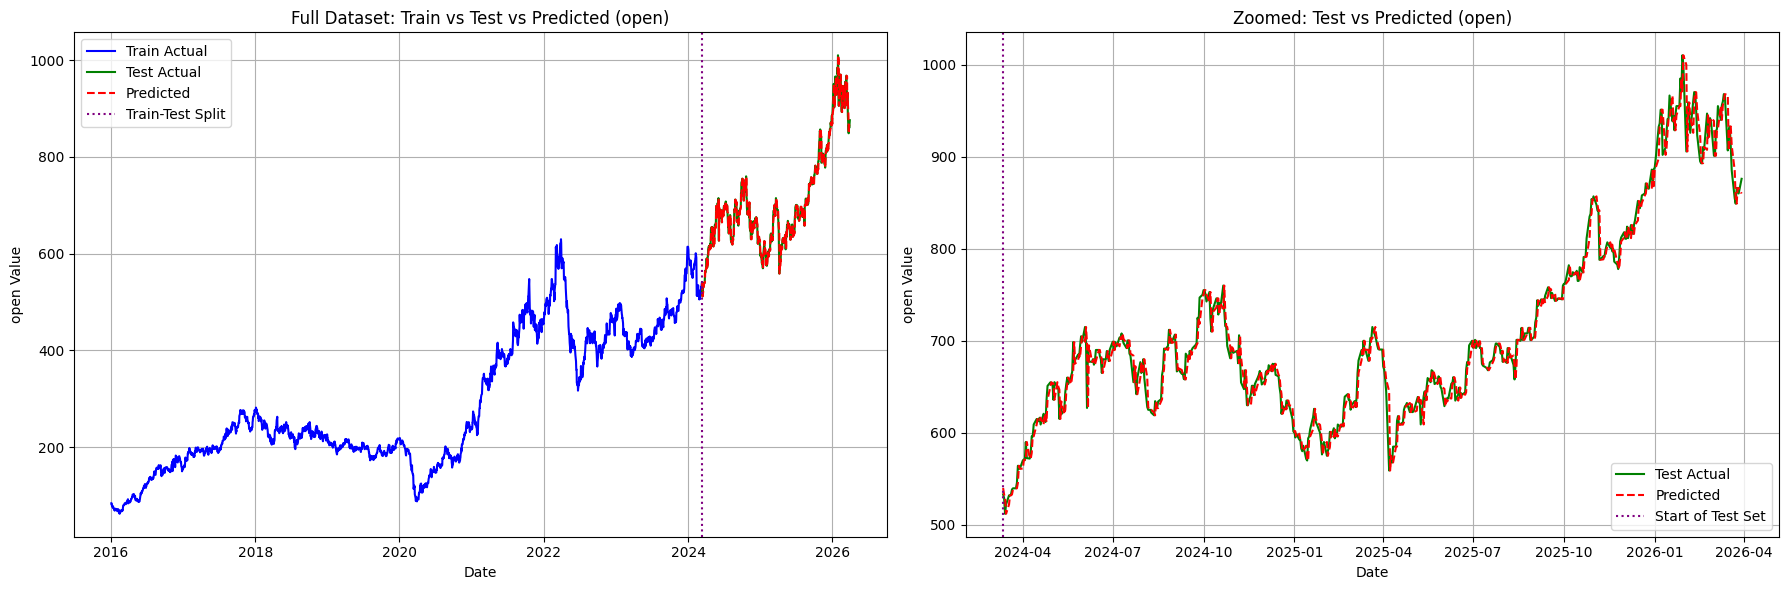


--- Processing column: high ---
Best ARIMA Order for high: (1, 1, 0)
Starting walk-forward validation for high (535 steps)...
  Step 50/535
  Step 100/535
  Step 150/535
  Step 200/535
  Step 250/535
  Step 300/535
  Step 350/535
  Step 400/535
  Step 450/535
  Step 500/535
RMSE for high: 11.973


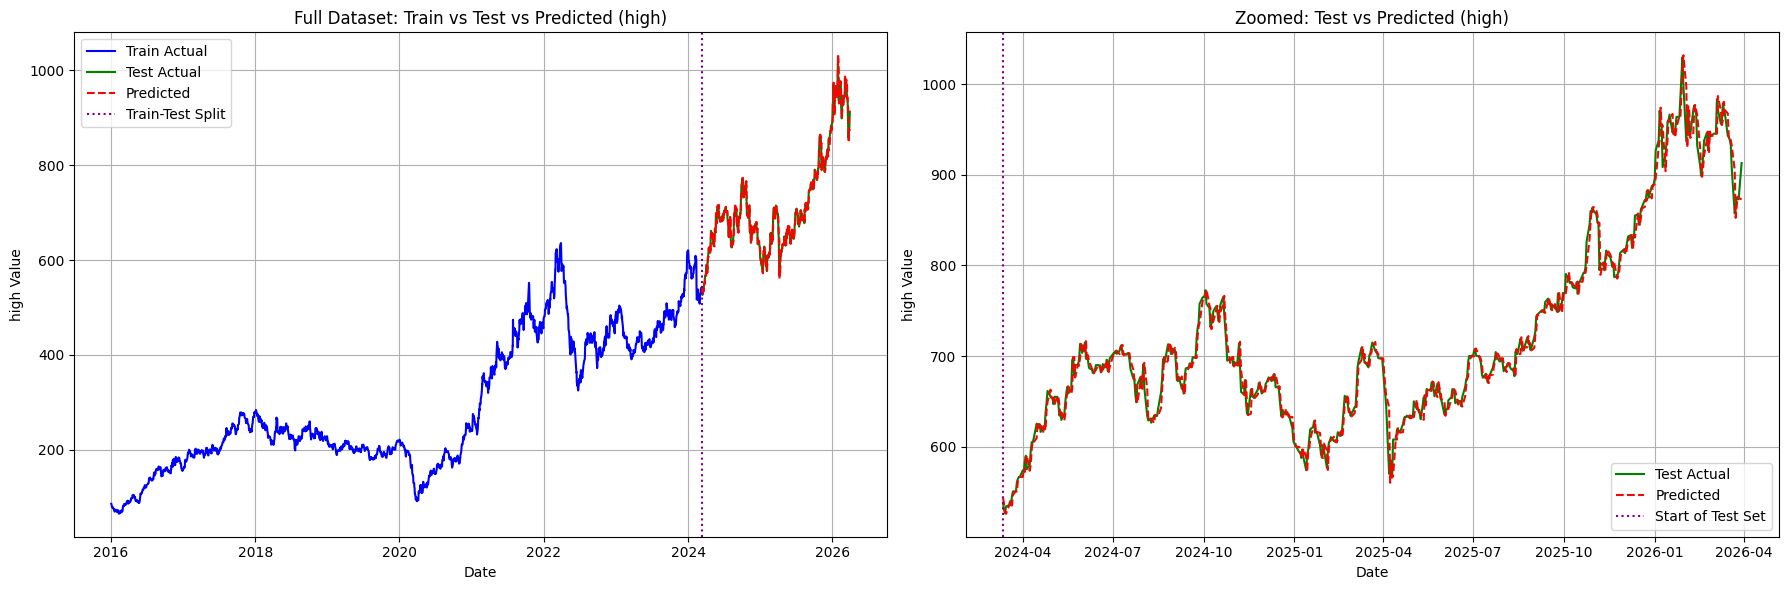


--- Processing column: low ---
Best ARIMA Order for low: (0, 1, 2)
Starting walk-forward validation for low (535 steps)...
  Step 50/535
  Step 100/535
  Step 150/535
  Step 200/535
  Step 250/535
  Step 300/535
  Step 350/535
  Step 400/535
  Step 450/535
  Step 500/535
RMSE for low: 13.318


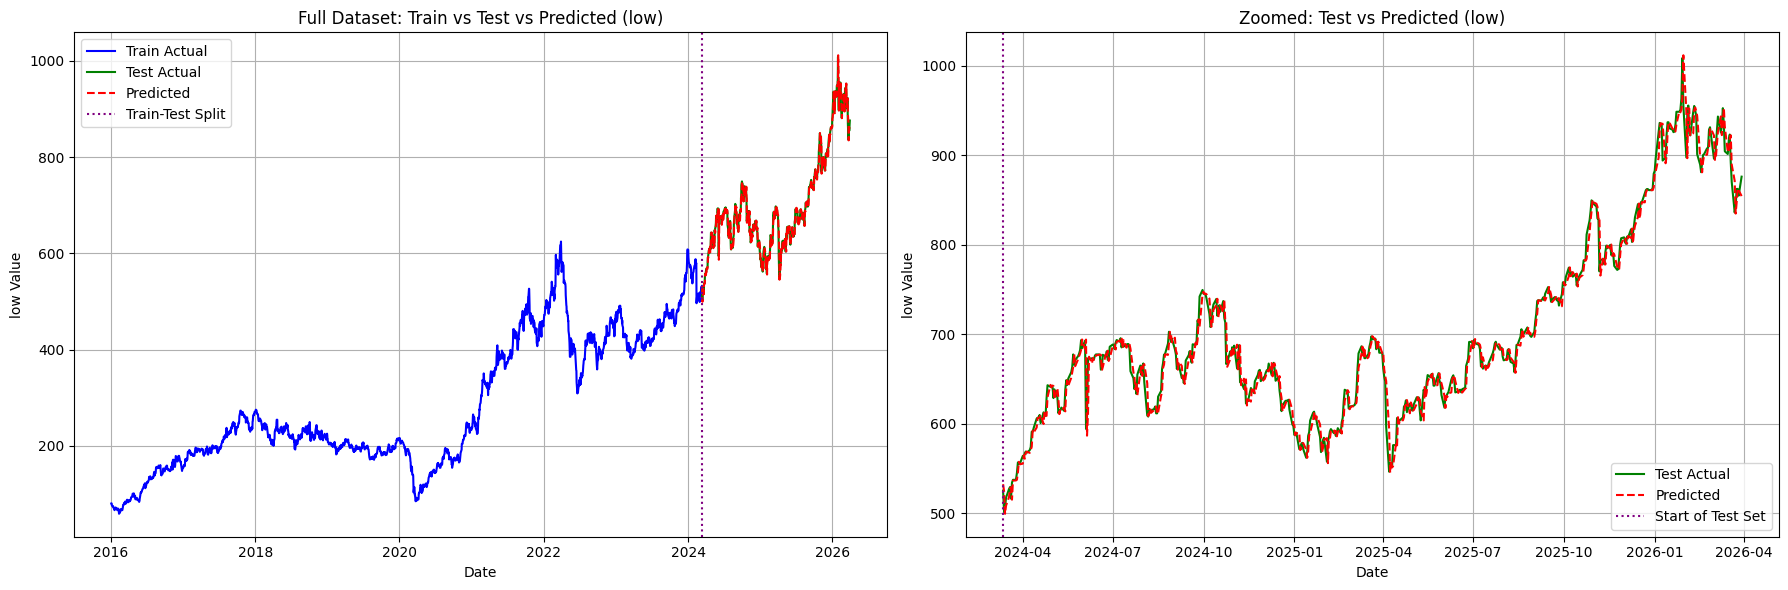


--- Processing column: close ---
Best ARIMA Order for close: (0, 1, 0)
Starting walk-forward validation for close (535 steps)...
  Step 50/535
  Step 100/535
  Step 150/535
  Step 200/535
  Step 250/535
  Step 300/535
  Step 350/535
  Step 400/535
  Step 450/535
  Step 500/535
RMSE for close: 13.056


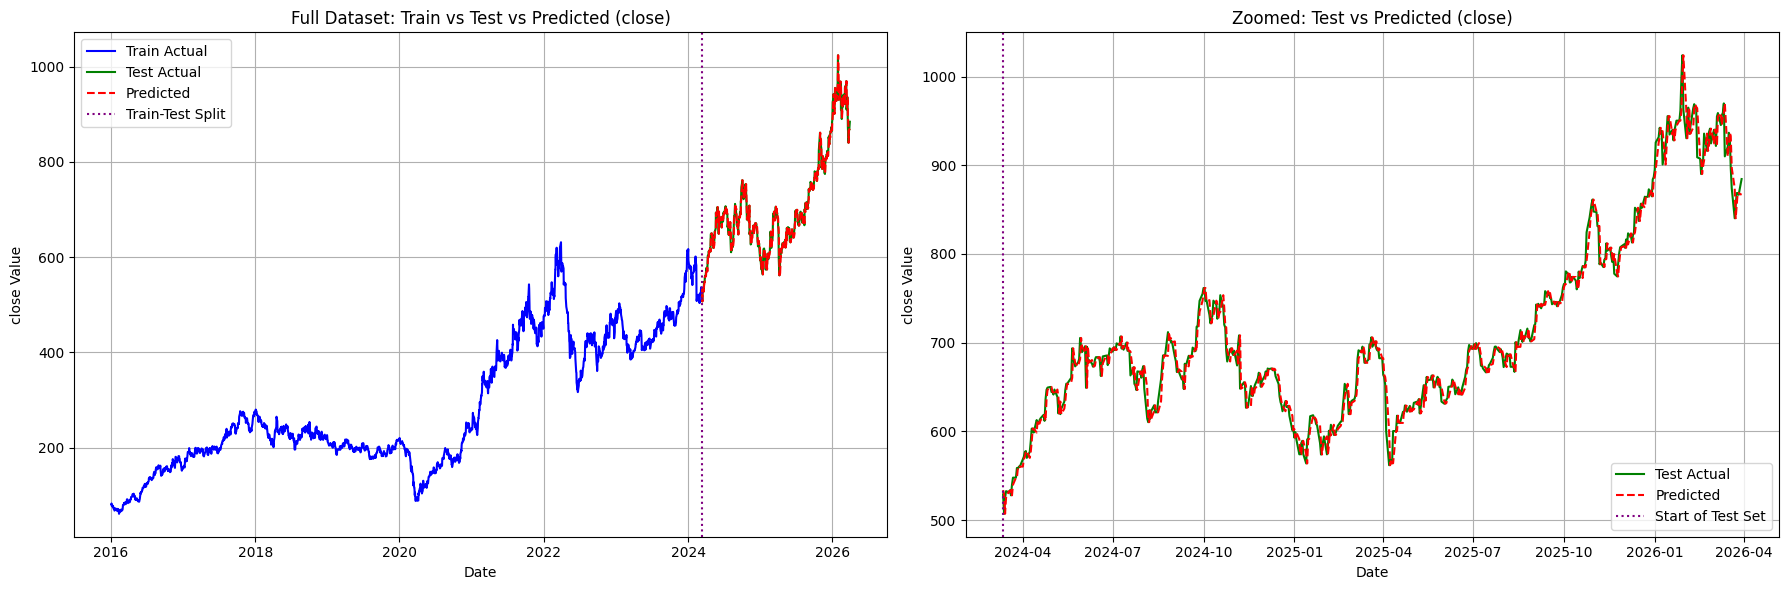


--- Processing column: volume ---
Best ARIMA Order for volume: (1, 1, 3)
Starting walk-forward validation for volume (535 steps)...
  Step 50/535
  Step 100/535
  Step 150/535
  Step 200/535
  Step 250/535
  Step 300/535
  Step 350/535
  Step 400/535
  Step 450/535
  Step 500/535
RMSE for volume: 3295762.855


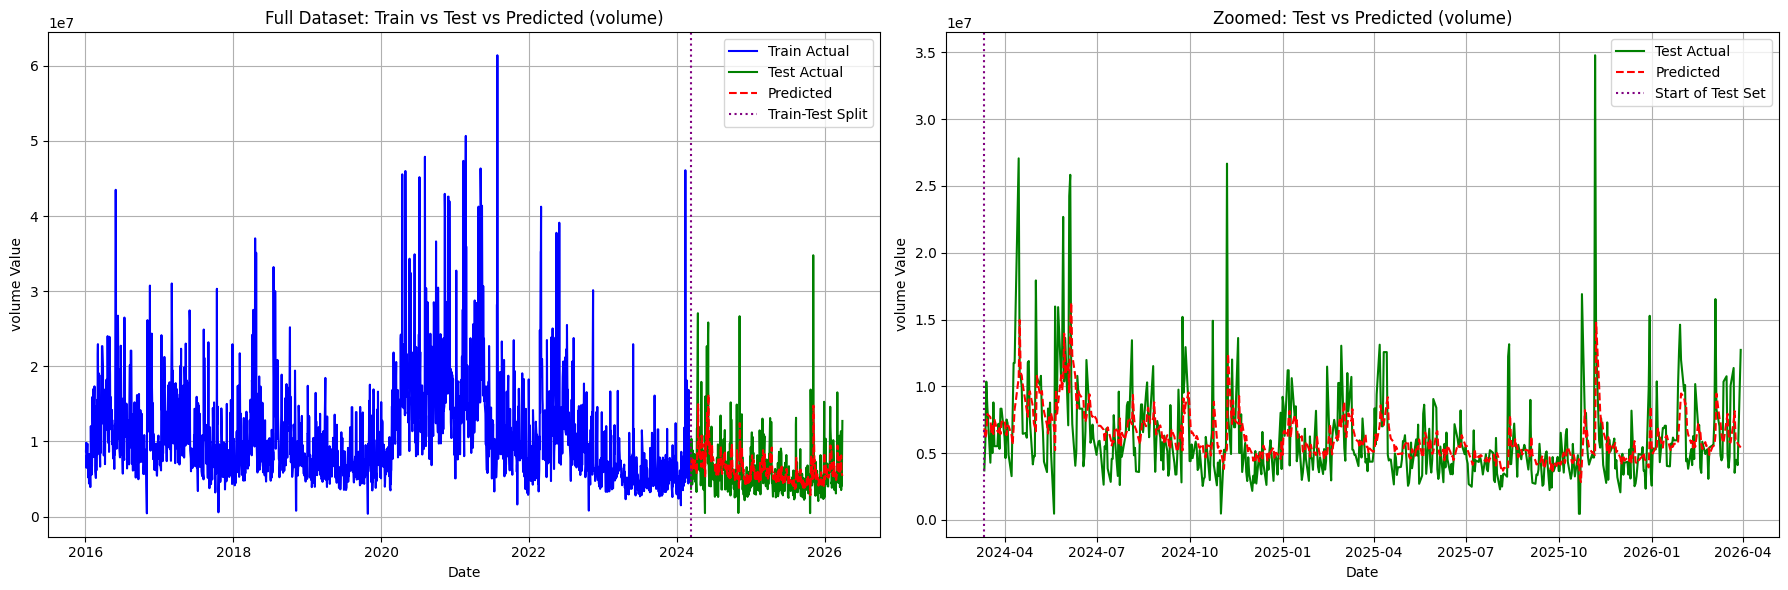

In [10]:
target_columns = ['open', 'high', 'low', 'close', 'volume']
results = []

for col in target_columns:
    if col not in df.columns:
        print(f"Skipping column '{col}' as it was not found in the DataFrame.")
        continue

    print(f"\n--- Processing column: {col} ---")
    series = df[col].dropna() # Drop any NaNs specific to this series

    # Split into train and test sets (80% train, 20% test)
    train_size = int(len(series) * 0.8)
    train, test = series[0:train_size], series[train_size:]

    # Find the best ARIMA order using auto_arima on the train set
    # seasonal=False as we are not explicitly looking for seasonality here given the short date range in example
    # and the prompt did not specify seasonal components.
    stepwise_fit = auto_arima(train, start_p=1, start_q=1, max_p=3, max_q=3,
                              m=1, d=None, seasonal=False, stepwise=True,
                              suppress_warnings=True, error_action='ignore',
                              maxiter=50, trace=False) # trace=True for more verbosity
    best_order = stepwise_fit.order
    print(f"Best ARIMA Order for {col}: {best_order}")

    # Walk-forward validation
    history = [x for x in train]
    predictions = []
    print(f"Starting walk-forward validation for {col} ({len(test)} steps)...")

    for i in range(len(test)):
        if (i + 1) % 50 == 0:
            print(f"  Step {i + 1}/{len(test)}")
        model = ARIMA(history, order=best_order)
        try:
            model_fit = model.fit(method='innovations_mle', low_memory=True)
            yhat = model_fit.forecast()[0]
            predictions.append(yhat)
            history.append(test[i]) # Append actual observation to history
        except Exception as e:
            print(f"  Error during forecast at step {i+1} for {col}: {e}")
            predictions.append(np.nan) # Append NaN if forecast fails
            history.append(test[i]) # Still append actual to move forward

    predictions_series = pd.Series(predictions, index=test.index)

    # Calculate RMSE
    # Only calculate RMSE for non-NaN predictions and corresponding test values
    valid_predictions = predictions_series.dropna()
    valid_test = test[valid_predictions.index]
    if not valid_test.empty:
        rmse = np.sqrt(mean_squared_error(valid_test, valid_predictions))
        print(f"RMSE for {col}: {rmse:.3f}")
    else:
        rmse = np.nan
        print(f"No valid predictions for {col} to calculate RMSE.")

    results.append({'Column': col, 'ARIMA Order': best_order, 'RMSE': rmse})

    # Plotting
    plt.figure(figsize=(18, 6))

    # Left subplot: Full view
    plt.subplot(1, 2, 1)
    plt.plot(train.index, train.values, color='blue', label='Train Actual')
    plt.plot(test.index, test.values, color='green', label='Test Actual')
    plt.plot(predictions_series.index, predictions_series.values, color='red', linestyle='--', label='Predicted')
    plt.axvline(x=train.index[-1], color='purple', linestyle=':', label='Train-Test Split')
    plt.title(f"Full Dataset: Train vs Test vs Predicted ({col})")
    plt.xlabel("Date")
    plt.ylabel(f"{col} Value")
    plt.legend()
    plt.grid(True)

    # Right subplot: Zoomed test-only view
    plt.subplot(1, 2, 2)
    plt.plot(test.index, test.values, color='green', label='Test Actual')
    plt.plot(predictions_series.index, predictions_series.values, color='red', linestyle='--', label='Predicted')
    plt.axvline(x=test.index[0], color='purple', linestyle=':', label='Start of Test Set')
    plt.title(f"Zoomed: Test vs Predicted ({col})")
    plt.xlabel("Date")
    plt.ylabel(f"{col} Value")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### Summary Table

Finally, here is a summary of the best ARIMA order and RMSE for each processed column.

In [11]:
print("\nSummary of ARIMA Results:")
print("Column     | ARIMA Order | RMSE")
print("-----------|-------------|------")
for res in results:
    col_name = res['Column'].ljust(10) # Left justify column name
    order_str = str(res['ARIMA Order']).ljust(11) # Left justify order
    rmse_val = f"{res['RMSE']:.3f}" if pd.notna(res['RMSE']) else 'N/A'
    print(f"{col_name} | {order_str} | {rmse_val}")


Summary of ARIMA Results:
Column     | ARIMA Order | RMSE
-----------|-------------|------
open       | (0, 1, 0)   | 14.519
high       | (1, 1, 0)   | 11.973
low        | (0, 1, 2)   | 13.318
close      | (0, 1, 0)   | 13.056
volume     | (1, 1, 3)   | 3295762.855
